# Lab 11: Centrality, Influence, and Importance

We have seen the notion of the center of a graph before. What if we want to look for not just the center of the graph, but the most important node(s) in their graph?

A node can be important if it
- has many neighbors,
- is close to all other nodes,
- is a part of many shortest paths, and
- is connected to other important nodes.

All of these ideas are not one-to-one. They lead to many different metrics that fall under the monkier 'centrality'. We will compare several different centrality measures, look for graphs where they disagree, and decide what each measure is actually telling us.

### Part 1: Familiar graphs, different kinds of importance

We will begin with the standard graph families we have been working with.

Question: which vertices seem most important, and why?

In [1]:
from lab11_helpers import *
import networkx as nx

In [2]:
# Some of the NetworkX centrality measures need scipy, so we will install it once
# this may take some time depending on your connection
!pip install scipy

In [3]:
P = path_graph(9)
C = cycle_graph(9)
S = star_graph(9)

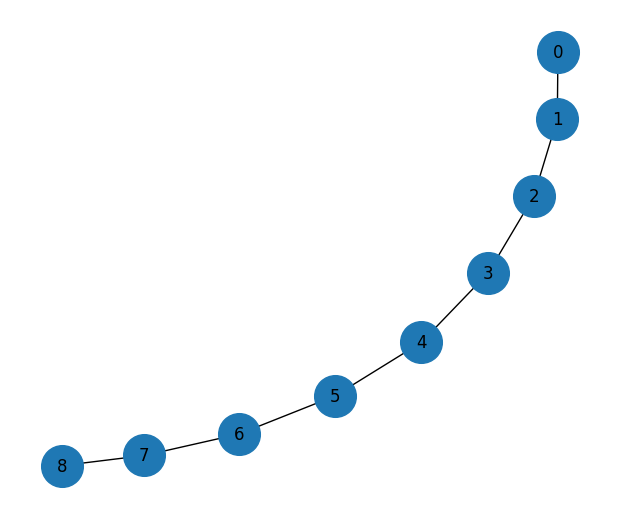

In [4]:
draw_graph(P)

In [5]:
centrality_table(P)

,degree,closeness,betweenness,eigenvector,pagerank
0,0.125,0.222222,0.000000,0.138199,0.071669
1,0.250,0.275862,0.250000,0.262869,0.129419
2,0.250,0.333333,0.428571,0.361804,0.121959
3,0.250,0.380952,0.535714,0.425323,0.118330
4,0.250,0.400000,0.571429,0.447210,0.117246
5,0.250,0.380952,0.535714,0.425323,0.118330
6,0.250,0.333333,0.428571,0.361804,0.121959
7,0.250,0.275862,0.250000,0.262869,0.129419
8,0.125,0.222222,0.000000,0.138199,0.071669


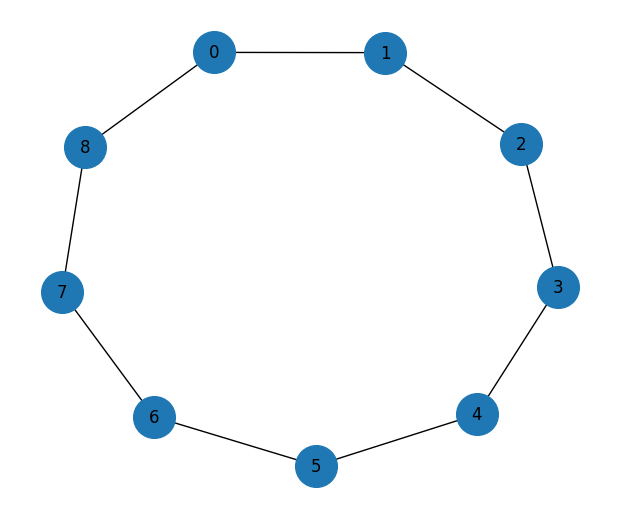

In [6]:
draw_graph(C)

In [7]:
centrality_table(C)

,degree,closeness,betweenness,eigenvector,pagerank
0,0.25,0.4,0.214286,0.333333,0.111111
1,0.25,0.4,0.214286,0.333333,0.111111
2,0.25,0.4,0.214286,0.333333,0.111111
3,0.25,0.4,0.214286,0.333333,0.111111
4,0.25,0.4,0.214286,0.333333,0.111111
5,0.25,0.4,0.214286,0.333333,0.111111
6,0.25,0.4,0.214286,0.333333,0.111111
7,0.25,0.4,0.214286,0.333333,0.111111
8,0.25,0.4,0.214286,0.333333,0.111111


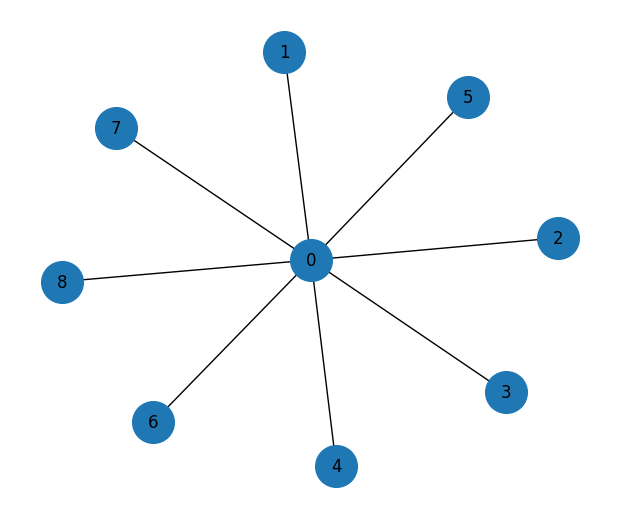

In [8]:
draw_graph(S)

In [9]:
centrality_table(S)

,degree,closeness,betweenness,eigenvector,pagerank
0,1.000,1.000000,1.0,0.707106,0.468470
1,0.125,0.533333,0.0,0.250000,0.066441
2,0.125,0.533333,0.0,0.250000,0.066441
3,0.125,0.533333,0.0,0.250000,0.066441
4,0.125,0.533333,0.0,0.250000,0.066441
5,0.125,0.533333,0.0,0.250000,0.066441
6,0.125,0.533333,0.0,0.250000,0.066441
7,0.125,0.533333,0.0,0.250000,0.066441
8,0.125,0.533333,0.0,0.250000,0.066441


Questions:
- In the path graph, which vertices are most central?
- In the cycle graph, do all vertices seem equally central?
- In the star graph, which vertex dominates every measure?
- Which measures seem to agree most strongly in these simple examples?

### Part 2: One graph, many answers

Now take a single graph and compute several centrality measures.

In [10]:
G = hub_bridge_graph()
graph_summary(G)

{'number_of_nodes': 9,
 'number_of_edges': 8,
 'nodes': ['H', 'A1', 'A2', 'A3', 'A4', 'B1', 'B2', 'B3', 'B4'],
 'edges': [('H', 'A1'),
  ('H', 'A2'),
  ('H', 'A3'),
  ('H', 'A4'),
  ('A4', 'B1'),
  ('B1', 'B2'),
  ('B2', 'B3'),
  ('B3', 'B4')],
 'degree_dict': {'H': 4,
  'A1': 1,
  'A2': 1,
  'A3': 1,
  'A4': 2,
  'B1': 2,
  'B2': 2,
  'B3': 2,
  'B4': 1}}

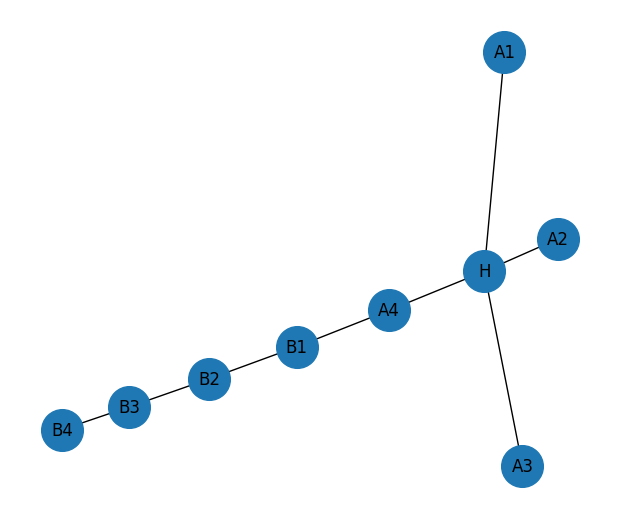

In [11]:
draw_graph(G)

In [12]:
centrality_table(G)

,degree,closeness,betweenness,eigenvector,pagerank
A1,0.125,0.320000,0.000000,0.296500,0.067318
A2,0.125,0.320000,0.000000,0.296500,0.067318
A3,0.125,0.320000,0.000000,0.296500,0.067318
A4,0.250,0.470588,0.571429,0.439180,0.117723
B1,0.250,0.444444,0.535714,0.302035,0.118601
B2,0.250,0.380952,0.428571,0.200189,0.122119
B3,0.250,0.307692,0.250000,0.121737,0.129526
B4,0.125,0.242424,0.000000,0.057509,0.071715
H,0.500,0.444444,0.642857,0.627658,0.238362


In [14]:
compare_rankings(G)

,degree,closeness,betweenness,eigenvector,pagerank,degree_rank,closeness_rank,betweenness_rank,eigenvector_rank,pagerank_rank
H,0.500,0.444444,0.642857,0.627658,0.238362,1.0,2.0,1.0,1.0,1.0
A4,0.250,0.470588,0.571429,0.439180,0.117723,2.0,1.0,2.0,2.0,5.0
B1,0.250,0.444444,0.535714,0.302035,0.118601,2.0,2.0,3.0,3.0,4.0
B2,0.250,0.380952,0.428571,0.200189,0.122119,2.0,4.0,4.0,7.0,3.0
B3,0.250,0.307692,0.250000,0.121737,0.129526,2.0,8.0,5.0,8.0,2.0
A1,0.125,0.320000,0.000000,0.296500,0.067318,6.0,5.0,6.0,4.0,7.0
A2,0.125,0.320000,0.000000,0.296500,0.067318,6.0,5.0,6.0,4.0,7.0
A3,0.125,0.320000,0.000000,0.296500,0.067318,6.0,5.0,6.0,4.0,7.0
B4,0.125,0.242424,0.000000,0.057509,0.071715,6.0,9.0,6.0,9.0,6.0


Questions:
- Which vertex has the highest degree centrality?
- Which vertex has the highest betweenness centrality?
- Are they the same?
- If not, what structural role does each seem to be capturing?

### Part 3: Betweenness and bottlenecks

Some vertices are important not because they have many neighbors, but because many shortest paths pass through them.

A bridge graph makes this easier to see.

In [15]:
B = bridge_graph()
graph_summary(B)

{'number_of_nodes': 8,
 'number_of_edges': 13,
 'nodes': [0, 1, 2, 3, 4, 5, 6, 7],
 'edges': [(0, 1),
  (0, 2),
  (0, 3),
  (1, 2),
  (1, 3),
  (2, 3),
  (3, 4),
  (4, 5),
  (4, 6),
  (4, 7),
  (5, 6),
  (5, 7),
  (6, 7)],
 'degree_dict': {0: 3, 1: 3, 2: 3, 3: 4, 4: 4, 5: 3, 6: 3, 7: 3}}

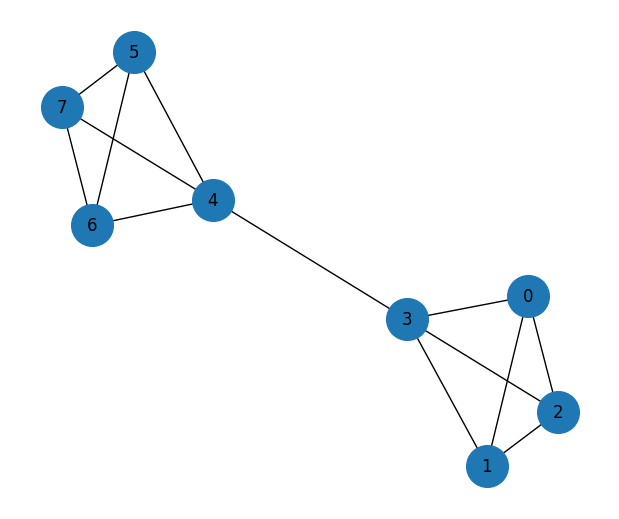

In [16]:
draw_graph(B)

In [17]:
centrality_table(B)

,degree,closeness,betweenness,eigenvector,pagerank
0,0.428571,0.5,0.000000,0.326260,0.116732
1,0.428571,0.5,0.000000,0.326260,0.116732
2,0.428571,0.5,0.000000,0.326260,0.116732
3,0.571429,0.7,0.571429,0.425044,0.149805
4,0.571429,0.7,0.571429,0.425044,0.149805
5,0.428571,0.5,0.000000,0.326260,0.116732
6,0.428571,0.5,0.000000,0.326260,0.116732
7,0.428571,0.5,0.000000,0.326260,0.116732


In [18]:
top_k_by_measure(B, measure="degree")

,degree,closeness,betweenness,eigenvector,pagerank
3,0.571429,0.7,0.571429,0.425044,0.149805
4,0.571429,0.7,0.571429,0.425044,0.149805
1,0.428571,0.5,0.000000,0.326260,0.116732
0,0.428571,0.5,0.000000,0.326260,0.116732
2,0.428571,0.5,0.000000,0.326260,0.116732


In [19]:
top_k_by_measure(B, measure="betweenness")

,degree,closeness,betweenness,eigenvector,pagerank
3,0.571429,0.7,0.571429,0.425044,0.149805
4,0.571429,0.7,0.571429,0.425044,0.149805
1,0.428571,0.5,0.000000,0.326260,0.116732
0,0.428571,0.5,0.000000,0.326260,0.116732
2,0.428571,0.5,0.000000,0.326260,0.116732


Questions:
- Which nodes connect the two dense parts of the graph?
- Which nodes have the largest betweenness?
- Are the highest-betweenness nodes also the ones with highest degree?
- Why might a bottleneck vertex be important even if it is not a hub?

### Part 4: Centrality in a real network

Now apply the same ideas to Zachary’s Karate Club graph.

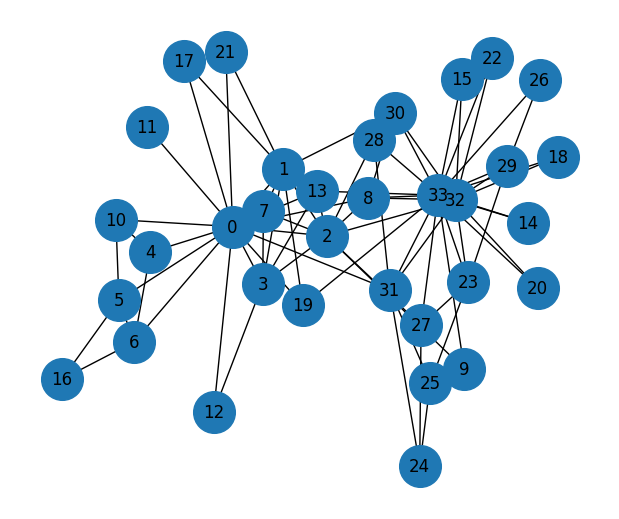

In [20]:
K = karate_graph()
draw_graph(K)

In [21]:
# Head will take the first 5 rows of the table, tail the last 5
centrality_table(K).head()

,degree,closeness,betweenness,eigenvector,pagerank
0,0.484848,0.568966,0.437635,0.355483,0.088508
1,0.272727,0.485294,0.053937,0.265954,0.057415
2,0.303030,0.559322,0.143657,0.317189,0.062767
3,0.181818,0.464789,0.011909,0.211174,0.037212
4,0.090909,0.379310,0.000631,0.075966,0.020504


In [22]:
compare_rankings(K)

,degree,closeness,betweenness,eigenvector,pagerank,degree_rank,closeness_rank,betweenness_rank,eigenvector_rank,pagerank_rank
33,0.515152,0.550000,0.304075,0.373371,0.096980,1.0,3.0,2.0,1.0,1.0
0,0.484848,0.568966,0.437635,0.355483,0.088508,2.0,1.0,1.0,2.0,2.0
32,0.363636,0.515625,0.145247,0.308651,0.075926,3.0,5.0,3.0,4.0,3.0
2,0.303030,0.559322,0.143657,0.317189,0.062767,4.0,2.0,4.0,3.0,4.0
1,0.272727,0.485294,0.053937,0.265954,0.057415,5.0,9.0,7.0,5.0,5.0
31,0.181818,0.540984,0.138276,0.191036,0.041985,6.0,4.0,5.0,9.0,6.0
3,0.181818,0.464789,0.011909,0.211174,0.037212,6.0,10.0,15.0,8.0,8.0
8,0.151515,0.515625,0.055927,0.227405,0.033382,8.0,5.0,6.0,6.0,11.0
13,0.151515,0.515625,0.045863,0.226470,0.033474,8.0,5.0,8.0,7.0,10.0
23,0.151515,0.392857,0.017614,0.150123,0.041146,8.0,16.0,13.0,12.0,7.0


Questions:
- Which vertices rank highly across several measures?
- Which vertices are highly ranked by one measure but not another?
- Does the graph appear to contain hubs, bottlenecks, or both?
- Which notion of “importance” seems most natural for this network?

### Part 5: Visualizing centrality in Gephi

Export B, G, and K to Gephi files. Size or color the vertices by the different centrality scores.
Save your visualizations and submit them along with the lab.

In Gephi:

1. Import one of the graphs.
2. Apply a layout.
3. Compute statistics if needed.
4. Size vertices by degree, then by betweenness, then by closeness.
5. Compare what changes visually.

Questions:
- Which centrality makes the bridge vertices stand out most clearly?
- Which centrality makes the hubs stand out most clearly?
- Does the visual ranking match the Python output?
- Which notion of centrality seems easiest to interpret visually?